<a href="https://colab.research.google.com/github/yasfmonteiro/Atividades-Estatistica-2026/blob/main/tarefa13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tarefa 13 — Distribuições de Probabilidade aplicadas às Ciências dos Alimentos

**Disciplina**: Estatistica aplicada às Ciências dos Alimentos

**Integrantes do grupo**
- Yasmin Agatha Acosta — 16905367
- Yasmin Dos Santos Almeida — 16992205
- Yasmin Victoria Ferreira Monteiro — 17068161

## Tema

Aplicação das distribuições Normal, t de Student, qui-quadrado e F de Fisher a dados físico-químicos de vinhos tintos e brancos.

## Objetivo

Investigar como as distribuições Normal, t de Student, qui-quadrado e F de Fisher podem ser utilizadas para modelar e analisar quantidades estatísticas relacionadas às características físico-químicas de vinhos, utilizando uma base de dados real da área de alimentos.

# 1. Base de dados

Foi utilizada a base **Wine Quality**, disponibilizada pelo **UCI Machine Learning Repository**.

A base contém dois conjuntos de dados relacionados a vinhos portugueses da região norte de Portugal: vinhos tintos e vinhos brancos. Os dados apresentam características físico-químicas obtidas por testes laboratoriais e uma variável de qualidade obtida por avaliação sensorial.

A base possui 4.898 observações e 11 variáveis físico-químicas, além da variável de qualidade. Não há valores ausentes registrados na documentação da base.

### Fonte

UCI Machine Learning Repository — Wine Quality:

https://archive.ics.uci.edu/dataset/186/wine+quality

### Referência da base

Cortez, P.; Cerdeira, A.; Almeida, F.; Matos, T.; Reis, J. (2009). *Wine Quality*. UCI Machine Learning Repository. DOI: 10.24432/C56S3T.

### Data de acesso

30 de setembro de 2026.

### Significado de cada linha

Cada linha representa uma amostra de vinho e contém seus respectivos valores para as características físico-químicas analisadas e para a avaliação de qualidade.

### Variáveis

| Variável | Significado | Unidade |
|---|---|---|
| fixed_acidity | acidez fixa | g/dm³ |
| volatile_acidity | acidez volátil | g/dm³ |
| citric_acid | ácido cítrico | g/dm³ |
| residual_sugar | açúcar residual | g/dm³ |
| chlorides | cloretos | g/dm³ |
| free_sulfur_dioxide | dióxido de enxofre livre | mg/dm³ |
| total_sulfur_dioxide | dióxido de enxofre total | mg/dm³ |
| density | densidade | g/cm³ |
| pH | potencial hidrogeniônico | adimensional |
| sulphates | sulfatos | g/dm³ |
| alcohol | teor alcoólico | % vol. |
| quality | qualidade sensorial | escala de 0 a 10 |

### Critério de seleção

Para as análises principais, será utilizada a variável **alcohol**, correspondente ao teor alcoólico dos vinhos, por ser uma variável quantitativa contínua adequada para a investigação das distribuições estatísticas.

A distinção entre vinho tinto e vinho branco será mantida para possibilitar a comparação entre dois grupos independentes na análise da distribuição F.

### Dados ausentes

Segundo a documentação do UCI, a base não apresenta valores ausentes. Essa informação também será verificada por meio do Python antes das análises.

### Licença

A base está disponível sob licença Creative Commons Attribution 4.0 International (CC BY 4.0).

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm, t, chi2, f

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [50]:
# Download das bases diretamente do UCI

url_red = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
url_white = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

red = pd.read_csv(url_red, sep=";")
white = pd.read_csv(url_white, sep=";")

red["tipo"] = "Tinto"
white["tipo"] = "Branco"

dados = pd.concat([red, white], ignore_index=True)

print("Dimensões do conjunto tinto:", red.shape)
print("Dimensões do conjunto branco:", white.shape)
print("Dimensões do conjunto total:", dados.shape)

Dimensões do conjunto tinto: (1599, 13)
Dimensões do conjunto branco: (4898, 13)
Dimensões do conjunto total: (6497, 13)


In [51]:
dados.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,tipo
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Tinto
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,Tinto
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,Tinto
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,Tinto
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Tinto


In [52]:
print("Informações da base:")
dados.info()

print("\nQuantidade de valores ausentes por variável:")
print(dados.isnull().sum())

Informações da base:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  tipo                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB

Quantidade de valores ausentes por variáv

In [53]:
print("Estatísticas descritivas do teor alcoólico:")

print(dados.groupby("tipo")["alcohol"].describe())

Estatísticas descritivas do teor alcoólico:
         count       mean       std  min  25%   50%   75%   max
tipo                                                           
Branco  4898.0  10.514267  1.230621  8.0  9.5  10.4  11.4  14.2
Tinto   1599.0  10.422983  1.065668  8.4  9.5  10.2  11.1  14.9


# 2. Análise exploratória

A variável escolhida para as principais análises é o **teor alcoólico (`alcohol`)**.

Essa variável é quantitativa contínua e apresenta valores individuais correspondentes às diferentes amostras de vinho.

A análise exploratória inicial permite observar a distribuição dos valores, sua tendência central e sua dispersão antes da aplicação das distribuições de probabilidade.

É importante diferenciar uma observação individual de uma estatística amostral.

Por exemplo:

- `alcohol = 12,5` representa uma observação individual de teor alcoólico;
- `mean(alcohol)` representa a média de uma amostra;
- `var(alcohol)` representa a variância de uma amostra.

As distribuições Normal, t, qui-quadrado e F serão utilizadas para representar quantidades diferentes, e não para afirmar automaticamente que os dados observados pertencem a essas distribuições.

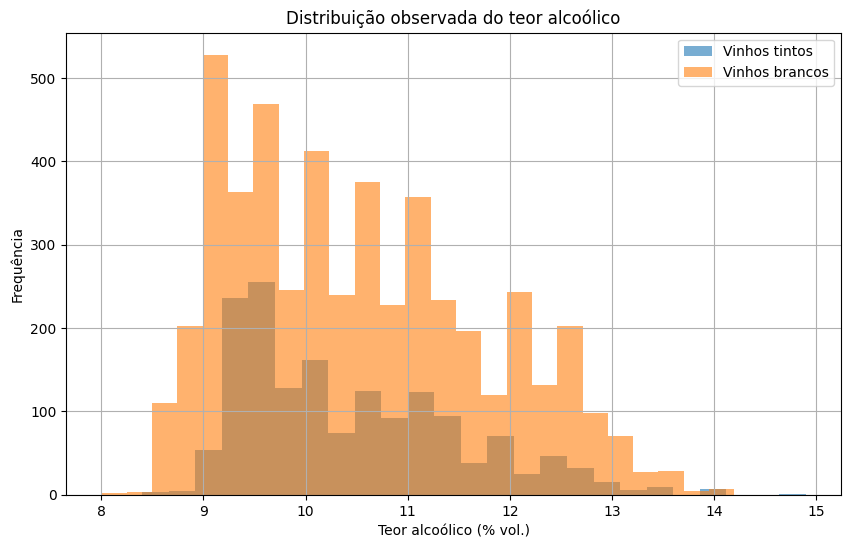

In [54]:
plt.figure(figsize=(10, 6))

plt.hist(red["alcohol"], bins=25, alpha=0.6, label="Vinhos tintos")
plt.hist(white["alcohol"], bins=25, alpha=0.6, label="Vinhos brancos")

plt.xlabel("Teor alcoólico (% vol.)")
plt.ylabel("Frequência")
plt.title("Distribuição observada do teor alcoólico")
plt.legend()

plt.show()

# 3. Distribuição Normal

A distribuição Normal é uma distribuição contínua e simétrica, caracterizada por dois parâmetros: média e desvio-padrão.

Sua função densidade de probabilidade é:

$$
f(x)=\frac{1}{\sigma\sqrt{2\pi}}e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}
$$

em que:

- \(x\) é o valor da variável aleatória;
- \(\mu\) é a média da distribuição;
- \(\sigma\) é o desvio-padrão;
- \(\sigma>0\);
- \(\pi\) é a constante matemática aproximadamente igual a 3,14159.

A média \(\mu\) determina a posição da curva no eixo horizontal. O aumento de \(\sigma\) aumenta a dispersão da distribuição, tornando a curva mais larga e menos concentrada em torno da média.

No contexto desta base, a distribuição Normal pode ser utilizada como um modelo teórico para o teor alcoólico dos vinhos. Entretanto, a construção da curva Normal não demonstra, por si só, que os dados observados seguem exatamente essa distribuição.

Para a aplicação, serão utilizados a média e o desvio-padrão observados no conjunto de vinhos brancos.

### Referência da fórmula

A parametrização da distribuição Normal utilizada neste trabalho segue a documentação da biblioteca SciPy:

SciPy Documentation. `scipy.stats.norm`.

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html

A documentação apresenta a Normal como uma variável aleatória contínua e utiliza `loc` para representar a localização e `scale` para representar o desvio-padrão.

In [55]:
mu = white["alcohol"].mean()
sigma = white["alcohol"].std()

print(f"Média do teor alcoólico dos vinhos brancos: {mu:.4f}%")
print(f"Desvio-padrão: {sigma:.4f}%")

Média do teor alcoólico dos vinhos brancos: 10.5143%
Desvio-padrão: 1.2306%


## 3.1 Efeito da média μ

Mantendo o desvio-padrão constante e alterando apenas a média, a curva Normal sofre deslocamento horizontal.

A forma e a dispersão permanecem iguais, mas o centro da distribuição muda.

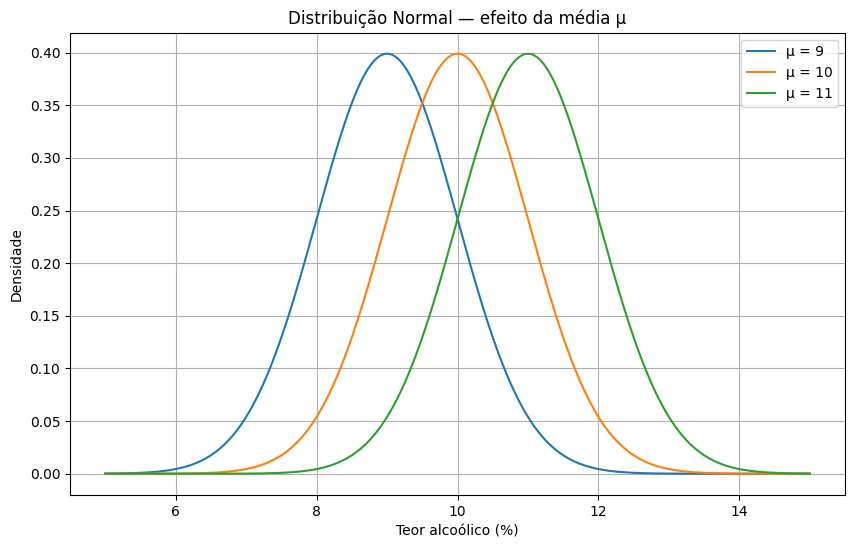

In [56]:
x = np.linspace(5, 15, 1000)

medias = [9, 10, 11]

plt.figure(figsize=(10, 6))

for m in medias:
    plt.plot(x, norm.pdf(x, m, 1), label=f"μ = {m}")

plt.xlabel("Teor alcoólico (%)")
plt.ylabel("Densidade")
plt.title("Distribuição Normal — efeito da média μ")
plt.legend()

plt.show()

### Interpretação

Quando a média aumenta, a curva se desloca para a direita. Quando a média diminui, a curva se desloca para a esquerda.

O desvio-padrão permanece igual, portanto a dispersão das curvas não é alterada.

## 3.2 Efeito do desvio-padrão σ

Agora a média será mantida constante e apenas o desvio-padrão será alterado.

O desvio-padrão deve ser maior que zero.

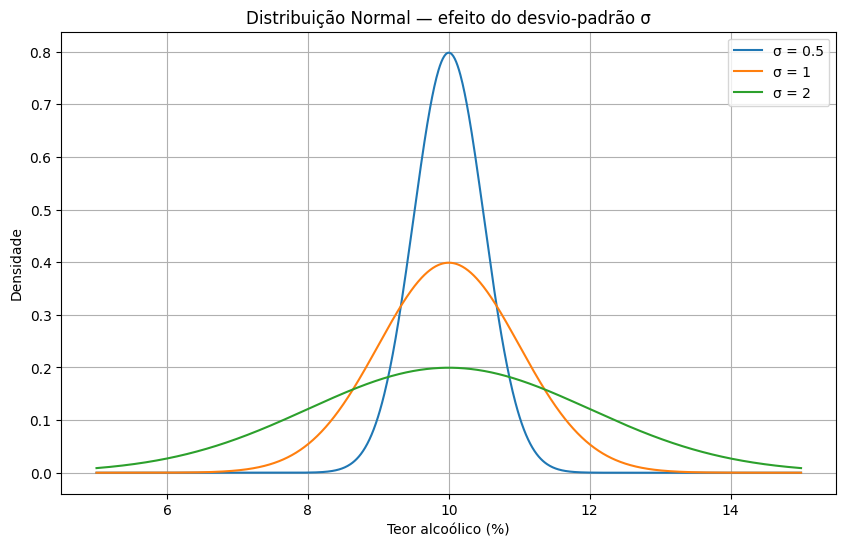

In [57]:
x = np.linspace(5, 15, 1000)

desvios = [0.5, 1, 2]

plt.figure(figsize=(10, 6))

for s in desvios:
    plt.plot(x, norm.pdf(x, 10, s), label=f"σ = {s}")

plt.xlabel("Teor alcoólico (%)")
plt.ylabel("Densidade")
plt.title("Distribuição Normal — efeito do desvio-padrão σ")
plt.legend()

plt.show()

### Interpretação

Quando o desvio-padrão aumenta, a distribuição fica mais espalhada e a altura máxima da curva diminui.

Quando o desvio-padrão diminui, os valores ficam mais concentrados ao redor da média e a curva fica mais estreita e alta.

Portanto:

- μ altera principalmente a posição da curva;
- σ altera principalmente a dispersão da curva.

## 3.3 Aplicação da Normal aos dados

Será utilizada a distribuição Normal com:

- média = média observada nos vinhos brancos;
- desvio-padrão = desvio-padrão observado nos vinhos brancos.

Pergunta:

**Qual é a probabilidade, segundo o modelo Normal ajustado aos dados dos vinhos brancos, de uma amostra apresentar teor alcoólico inferior ou igual a 11%?**

In [58]:
limite = 11

prob_acumulada = norm.cdf(limite, loc=mu, scale=sigma)

print(f"P(X ≤ {limite}) = {prob_acumulada:.4f}")
print(f"Percentual = {prob_acumulada*100:.2f}%")

P(X ≤ 11) = 0.6535
Percentual = 65.35%


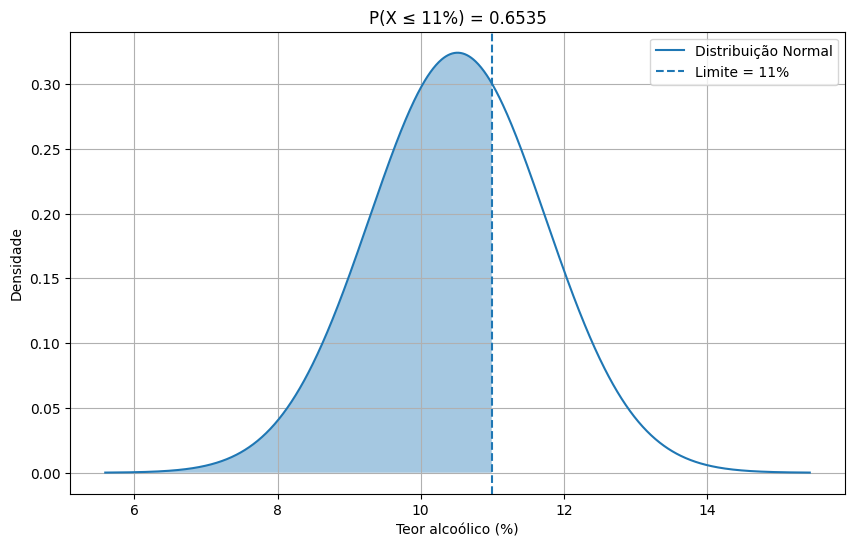

In [59]:
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)

plt.figure(figsize=(10, 6))

plt.plot(x, y, label="Distribuição Normal")

x_fill = x[x <= limite]
y_fill = norm.pdf(x_fill, mu, sigma)

plt.fill_between(x_fill, y_fill, alpha=0.4)

plt.axvline(limite, linestyle="--", label=f"Limite = {limite}%")

plt.title(f"P(X ≤ {limite}%) = {prob_acumulada:.4f}")
plt.xlabel("Teor alcoólico (%)")
plt.ylabel("Densidade")
plt.legend()

plt.show()

### Probabilidade entre dois valores

Pergunta:

**Qual é a probabilidade de um vinho branco apresentar, segundo o modelo Normal, teor alcoólico entre 10% e 12%?**

In [60]:
a = 10
b = 12

prob_intervalo = norm.cdf(b, mu, sigma) - norm.cdf(a, mu, sigma)

print(f"P({a} < X < {b}) = {prob_intervalo:.4f}")
print(f"Percentual = {prob_intervalo*100:.2f}%")

P(10 < X < 12) = 0.5483
Percentual = 54.83%


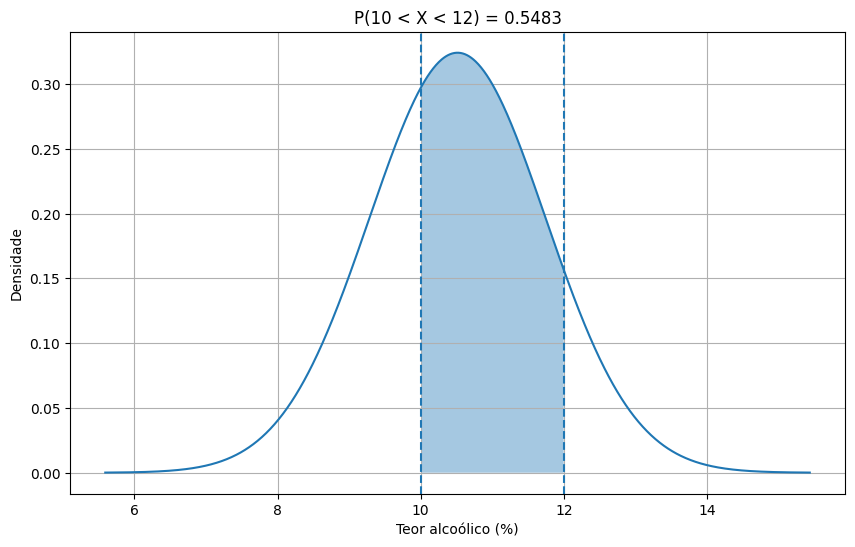

In [61]:
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)

plt.figure(figsize=(10, 6))
plt.plot(x, y)

x_fill = x[(x >= a) & (x <= b)]
y_fill = norm.pdf(x_fill, mu, sigma)

plt.fill_between(x_fill, y_fill, alpha=0.4)

plt.axvline(a, linestyle="--")
plt.axvline(b, linestyle="--")

plt.title(f"P({a} < X < {b}) = {prob_intervalo:.4f}")
plt.xlabel("Teor alcoólico (%)")
plt.ylabel("Densidade")

plt.show()

### Probabilidade acima de um valor

Pergunta:

**Qual é a probabilidade de um vinho branco apresentar teor alcoólico superior a 12%?**

In [62]:
limite_superior = 12

prob_acima = norm.sf(limite_superior, mu, sigma)

print(f"P(X > {limite_superior}) = {prob_acima:.4f}")
print(f"Percentual = {prob_acima*100:.2f}%")

P(X > 12) = 0.1137
Percentual = 11.37%


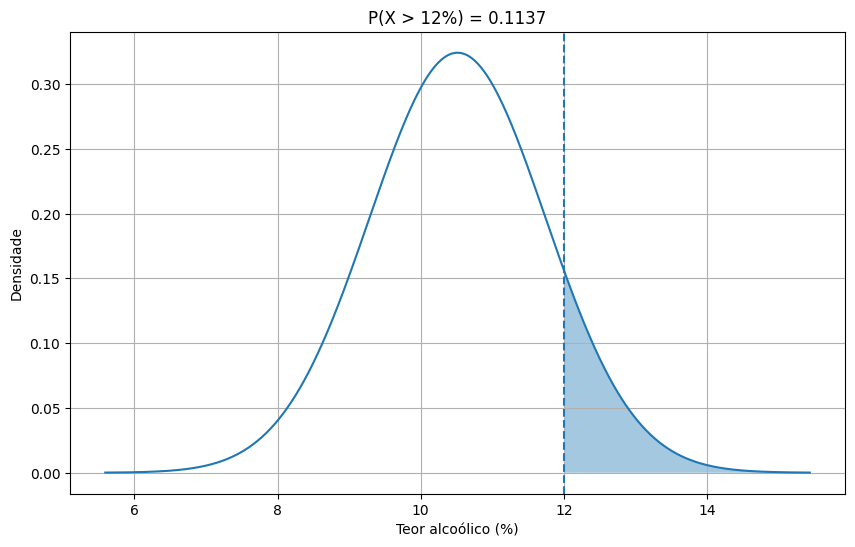

In [63]:
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)

plt.figure(figsize=(10, 6))
plt.plot(x, y)

x_fill = x[x >= limite_superior]
y_fill = norm.pdf(x_fill, mu, sigma)

plt.fill_between(x_fill, y_fill, alpha=0.4)

plt.axvline(limite_superior, linestyle="--")

plt.title(f"P(X > {limite_superior}%) = {prob_acima:.4f}")
plt.xlabel("Teor alcoólico (%)")
plt.ylabel("Densidade")

plt.show()

## 3.4 Percentil da distribuição Normal

Será calculado o percentil 95%.

O percentil 95 corresponde ao valor que deixa aproximadamente 95% da distribuição abaixo dele e 5% acima.

In [64]:
percentil_95_normal = norm.ppf(0.95, mu, sigma)

print(f"Percentil 95% = {percentil_95_normal:.4f}%")

Percentil 95% = 12.5385%


### Interpretação

O percentil 95% indica um valor de teor alcoólico tal que aproximadamente 95% da distribuição Normal ajustada aos vinhos brancos apresenta valores iguais ou inferiores a ele.

Esse resultado representa uma propriedade do modelo probabilístico utilizado e não significa que exatamente 95% das observações individuais da base estejam abaixo desse valor.

# 4. Distribuição t de Student

A distribuição t de Student é utilizada principalmente em situações envolvendo inferência sobre médias quando o desvio-padrão populacional é desconhecido.

Sua função densidade é:

$$
f(t)=\frac{\Gamma\left(\frac{\nu+1}{2}\right)}{\sqrt{\nu\pi}\Gamma\left(\frac{\nu}{2}\right)}\left(1+\frac{t^2}{\nu}\right)^{-\frac{\nu+1}{2}}
$$

em que:

- \(t\) é o valor da variável aleatória;
- \(\nu\) representa os graus de liberdade;
- \(\Gamma\) é a função gama;
- \(\nu>0\).

No caso de inferência sobre uma média, uma estatística t pode ser calculada por:

$$
T=\frac{\bar X-\mu_0}{S/\sqrt{n}}
$$

em que:

- \(\bar X\) é a média amostral;
- \(\mu_0\) é uma média de referência;
- \(S\) é o desvio-padrão amostral;
- \(n\) é o tamanho da amostra;
- os graus de liberdade são \(\nu=n-1\).

Nesta análise será utilizada uma amostra de 25 vinhos brancos.

### Referência

A formulação da distribuição t e suas funções estatísticas são apresentadas na documentação da SciPy:

SciPy Documentation — `scipy.stats.t`

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html

A distribuição é parametrizada principalmente pelos graus de liberdade.

In [65]:
# Seleção reprodutível de uma amostra de 25 vinhos brancos

amostra_t = white["alcohol"].sample(n=25, random_state=42)

n = len(amostra_t)
media_amostra = amostra_t.mean()
desvio_amostra = amostra_t.std(ddof=1)

# Média de referência escolhida para a análise
mu0 = 10.5

df_t = n - 1

t_obs = (media_amostra - mu0) / (desvio_amostra / np.sqrt(n))

print(f"Tamanho da amostra: {n}")
print(f"Média amostral: {media_amostra:.4f}%")
print(f"Desvio-padrão amostral: {desvio_amostra:.4f}%")
print(f"Média de referência: {mu0:.2f}%")
print(f"Graus de liberdade: {df_t}")
print(f"Estatística t observada: {t_obs:.4f}")

Tamanho da amostra: 25
Média amostral: 10.7227%
Desvio-padrão amostral: 1.2824%
Média de referência: 10.50%
Graus de liberdade: 24
Estatística t observada: 0.8682


## 4.1 Efeito dos graus de liberdade

A distribuição t depende dos graus de liberdade.

Para graus de liberdade pequenos, a distribuição apresenta caudas mais pesadas que a Normal.

À medida que os graus de liberdade aumentam, a distribuição t se aproxima da distribuição Normal padrão.

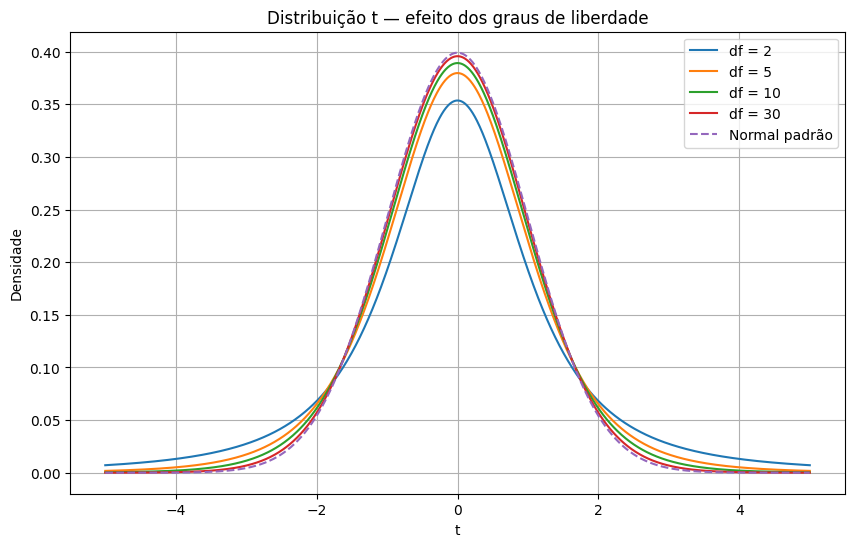

In [66]:
x = np.linspace(-5, 5, 1000)

graus_liberdade = [2, 5, 10, 30]

plt.figure(figsize=(10, 6))

for df in graus_liberdade:
    plt.plot(x, t.pdf(x, df), label=f"df = {df}")

plt.plot(x, norm.pdf(x), linestyle="--", label="Normal padrão")

plt.xlabel("t")
plt.ylabel("Densidade")
plt.title("Distribuição t — efeito dos graus de liberdade")
plt.legend()

plt.show()

### Interpretação

Com poucos graus de liberdade, as caudas da distribuição t são mais pesadas, refletindo a maior incerteza associada à estimativa do desvio-padrão populacional.

À medida que os graus de liberdade aumentam, essa incerteza diminui e a distribuição t se aproxima da Normal padrão.

## 4.2 Aplicação da distribuição t

Pergunta:

**Considerando uma amostra aleatória de 25 vinhos brancos e uma média de referência de 10,5% de álcool, qual é a probabilidade de obter uma estatística t menor ou igual à estatística observada na amostra?**

A média de referência de 10,5% é utilizada exclusivamente como valor de referência para a atividade estatística. Ela não representa um limite regulamentar nem uma recomendação para vinhos.

In [67]:
prob_t_acumulada = t.cdf(t_obs, df_t)

print(f"P(T ≤ {t_obs:.4f}) = {prob_t_acumulada:.4f}")

P(T ≤ 0.8682) = 0.8031


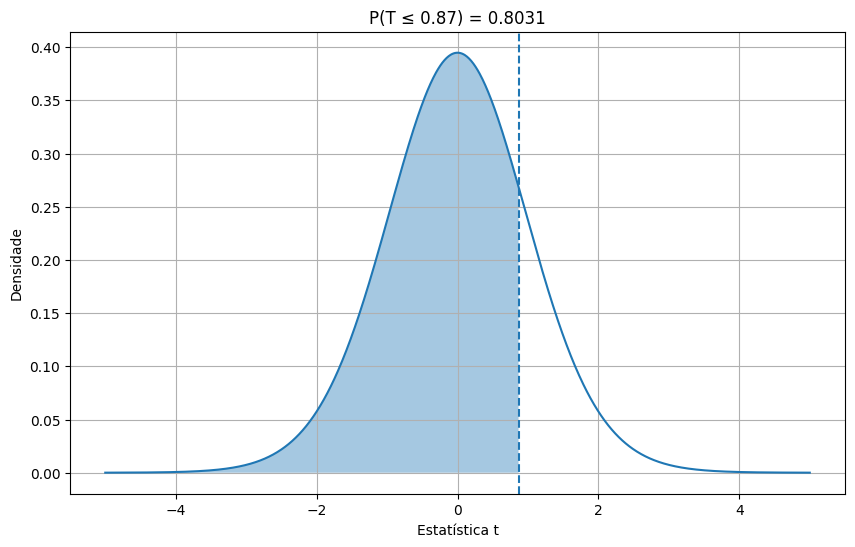

In [68]:
x = np.linspace(-5, 5, 1000)
y = t.pdf(x, df_t)

plt.figure(figsize=(10, 6))
plt.plot(x, y)

x_fill = x[x <= t_obs]
y_fill = t.pdf(x_fill, df_t)

plt.fill_between(x_fill, y_fill, alpha=0.4)

plt.axvline(t_obs, linestyle="--")

plt.title(f"P(T ≤ {t_obs:.2f}) = {prob_t_acumulada:.4f}")
plt.xlabel("Estatística t")
plt.ylabel("Densidade")

plt.show()

## 4.3 Probabilidade entre dois valores

Pergunta:

**Qual é a probabilidade de a estatística t estar entre -2 e 2 para uma distribuição t com 24 graus de liberdade?**

In [69]:
a_t = -2
b_t = 2

prob_t_intervalo = t.cdf(b_t, df_t) - t.cdf(a_t, df_t)

print(f"P({a_t} < T < {b_t}) = {prob_t_intervalo:.4f}")

P(-2 < T < 2) = 0.9431


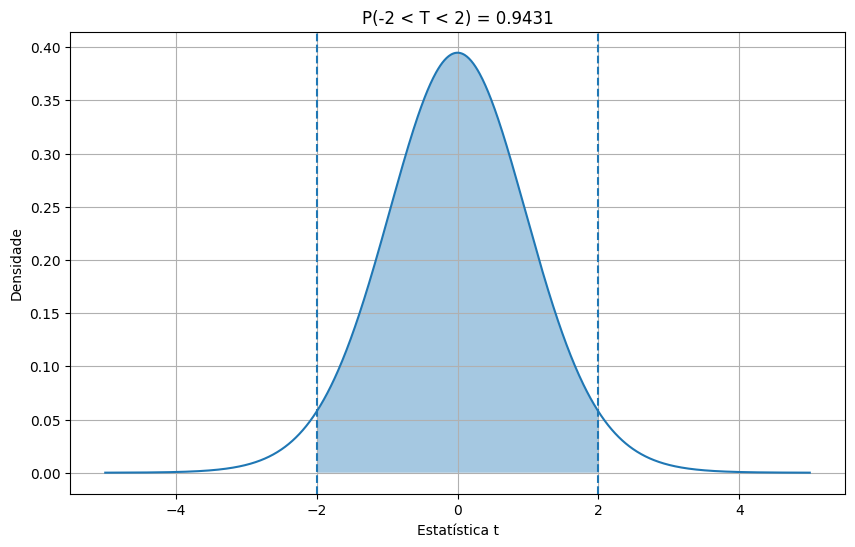

In [70]:
x = np.linspace(-5, 5, 1000)
y = t.pdf(x, df_t)

plt.figure(figsize=(10, 6))
plt.plot(x, y)

x_fill = x[(x >= a_t) & (x <= b_t)]
y_fill = t.pdf(x_fill, df_t)

plt.fill_between(x_fill, y_fill, alpha=0.4)

plt.axvline(a_t, linestyle="--")
plt.axvline(b_t, linestyle="--")

plt.title(f"P(-2 < T < 2) = {prob_t_intervalo:.4f}")
plt.xlabel("Estatística t")
plt.ylabel("Densidade")

plt.show()

## 4.4 Probabilidade acima de um valor

Pergunta:

**Qual é a probabilidade de uma estatística t com 24 graus de liberdade ser superior a 2?**

In [71]:
limite_t = 2

prob_t_acima = t.sf(limite_t, df_t)

print(f"P(T > {limite_t}) = {prob_t_acima:.4f}")

P(T > 2) = 0.0285


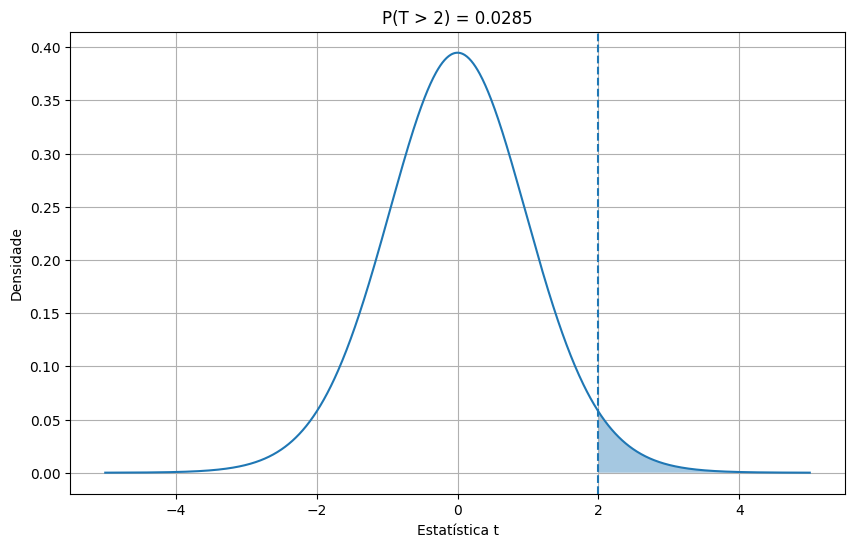

In [72]:
x = np.linspace(-5, 5, 1000)
y = t.pdf(x, df_t)

plt.figure(figsize=(10, 6))
plt.plot(x, y)

x_fill = x[x >= limite_t]
y_fill = t.pdf(x_fill, df_t)

plt.fill_between(x_fill, y_fill, alpha=0.4)

plt.axvline(limite_t, linestyle="--")

plt.title(f"P(T > {limite_t}) = {prob_t_acima:.4f}")
plt.xlabel("Estatística t")
plt.ylabel("Densidade")

plt.show()

In [73]:
percentil_95_t = t.ppf(0.95, df_t)

print(f"Percentil 95% da distribuição t com {df_t} graus de liberdade: {percentil_95_t:.4f}")

Percentil 95% da distribuição t com 24 graus de liberdade: 1.7109


### Interpretação

O percentil 95% da distribuição t representa o valor que deixa 95% da área da distribuição abaixo dele.

Esse valor é uma propriedade da distribuição t para os graus de liberdade utilizados e pode ser utilizado como referência para interpretar estatísticas t em análises inferenciais.

# 5. Distribuição qui-quadrado

A distribuição qui-quadrado é uma distribuição contínua definida para valores não negativos e caracterizada pelos graus de liberdade.

Sua função densidade é:

$$
f(x)=\frac{1}{2^{\nu/2}\Gamma(\nu/2)}x^{\nu/2-1}e^{-x/2}
$$

para:

$$
x>0
$$

e:

$$
\nu>0
$$

em que:

- \(x\) é o valor da variável aleatória;
- \(\nu\) representa os graus de liberdade;
- \(\Gamma\) é a função gama.

Uma aplicação importante da distribuição qui-quadrado ocorre na inferência sobre a variância de uma população Normal. Nesse caso:

$$
\chi^2 = \frac{(n-1)S^2}{\sigma_0^2}
$$

em que:

- \(n\) é o tamanho da amostra;
- \(S^2\) é a variância amostral;
- \(\sigma_0^2\) é uma variância populacional de referência;
- os graus de liberdade são \(n-1\).

Nesta atividade será utilizada uma amostra de 30 vinhos brancos.

### Referência

SciPy Documentation — `scipy.stats.chi2`

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2.html

A documentação da SciPy apresenta a distribuição qui-quadrado em função dos graus de liberdade.

In [74]:
# Amostra de 30 vinhos brancos

amostra_chi = white["alcohol"].sample(n=30, random_state=123)

n_chi = len(amostra_chi)
variancia_amostral = amostra_chi.var(ddof=1)

# Variância de referência escolhida para a atividade
sigma0_quadrado = 1.0

df_chi = n_chi - 1

chi_obs = ((n_chi - 1) * variancia_amostral) / sigma0_quadrado

print(f"Tamanho da amostra: {n_chi}")
print(f"Variância amostral: {variancia_amostral:.4f}")
print(f"Variância de referência: {sigma0_quadrado:.2f}")
print(f"Graus de liberdade: {df_chi}")
print(f"Estatística qui-quadrado observada: {chi_obs:.4f}")

Tamanho da amostra: 30
Variância amostral: 1.4173
Variância de referência: 1.00
Graus de liberdade: 29
Estatística qui-quadrado observada: 41.1030


## 5.1 Efeito dos graus de liberdade

A distribuição qui-quadrado apresenta assimetria positiva, especialmente quando possui poucos graus de liberdade.

Com o aumento dos graus de liberdade, a distribuição se desloca para valores maiores e sua forma se torna progressivamente menos assimétrica.

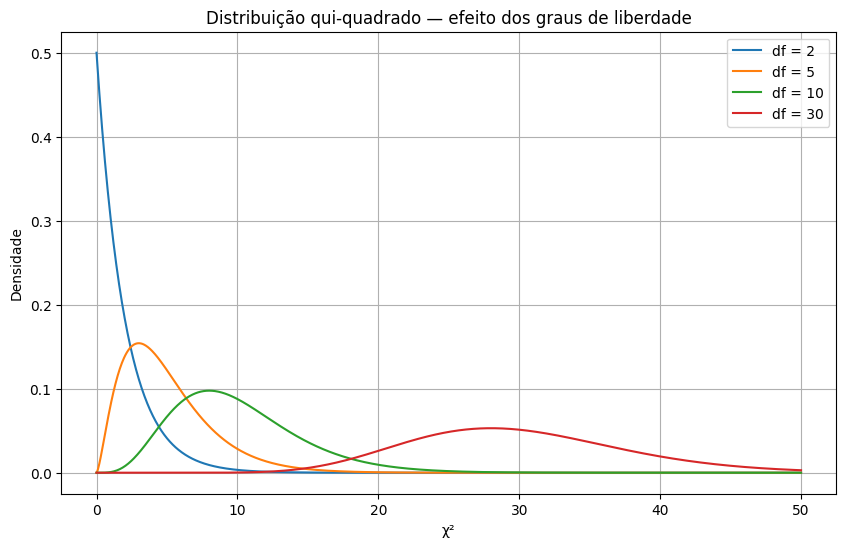

In [75]:
x = np.linspace(0, 50, 1000)

graus_liberdade_chi = [2, 5, 10, 30]

plt.figure(figsize=(10, 6))

for df in graus_liberdade_chi:
    plt.plot(x, chi2.pdf(x, df), label=f"df = {df}")

plt.xlabel("χ²")
plt.ylabel("Densidade")
plt.title("Distribuição qui-quadrado — efeito dos graus de liberdade")
plt.legend()

plt.show()

## 5.2 Aplicação

Pergunta:

**Qual é a probabilidade de uma estatística qui-quadrado com 29 graus de liberdade ser menor ou igual ao valor observado na amostra de vinhos brancos?**

A variância de referência utilizada na atividade é

$$
1,0\;(\%\text{ de álcool})^2
$$

Esse valor foi definido como referência didática para a aplicação da distribuição e não representa um limite regulamentar.

In [76]:
prob_chi_acumulada = chi2.cdf(chi_obs, df_chi)

print(f"P(χ² ≤ {chi_obs:.4f}) = {prob_chi_acumulada:.4f}")

P(χ² ≤ 41.1030) = 0.9325


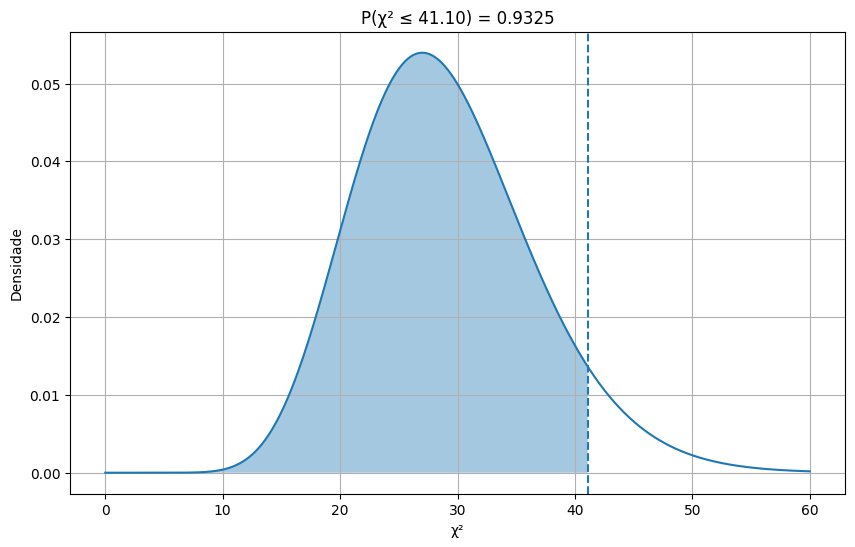

In [77]:
x = np.linspace(0, max(60, chi_obs + 10), 1000)
y = chi2.pdf(x, df_chi)

plt.figure(figsize=(10, 6))
plt.plot(x, y)

x_fill = x[x <= chi_obs]
y_fill = chi2.pdf(x_fill, df_chi)

plt.fill_between(x_fill, y_fill, alpha=0.4)

plt.axvline(chi_obs, linestyle="--")

plt.title(f"P(χ² ≤ {chi_obs:.2f}) = {prob_chi_acumulada:.4f}")
plt.xlabel("χ²")
plt.ylabel("Densidade")

plt.show()

## 5.3 Probabilidade entre dois valores

Pergunta:

**Qual é a probabilidade de uma variável qui-quadrado com 29 graus de liberdade assumir um valor entre 20 e 40?**

In [78]:
a_chi = 20
b_chi = 40

prob_chi_intervalo = chi2.cdf(b_chi, df_chi) - chi2.cdf(a_chi, df_chi)

print(f"P({a_chi} < χ² < {b_chi}) = {prob_chi_intervalo:.4f}")

P(20 < χ² < 40) = 0.8090


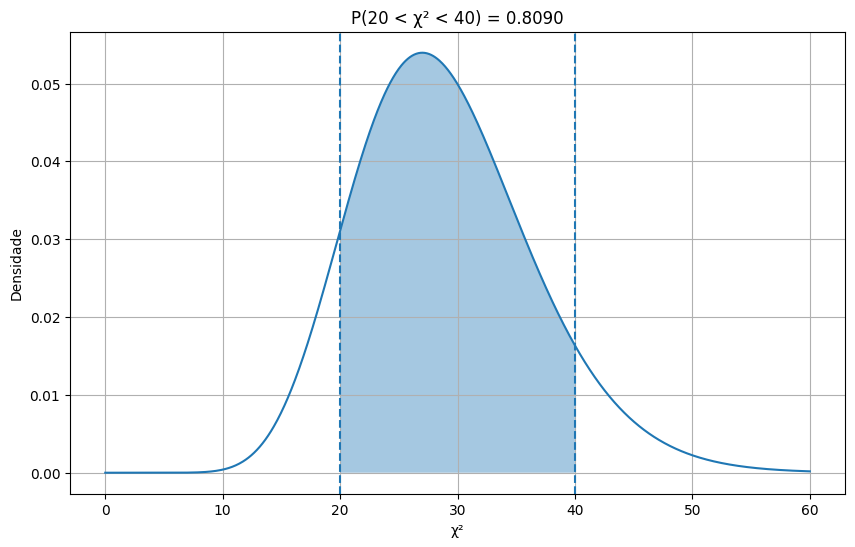

In [79]:
x = np.linspace(0, 60, 1000)
y = chi2.pdf(x, df_chi)

plt.figure(figsize=(10, 6))
plt.plot(x, y)

x_fill = x[(x >= a_chi) & (x <= b_chi)]
y_fill = chi2.pdf(x_fill, df_chi)

plt.fill_between(x_fill, y_fill, alpha=0.4)

plt.axvline(a_chi, linestyle="--")
plt.axvline(b_chi, linestyle="--")

plt.title(f"P({a_chi} < χ² < {b_chi}) = {prob_chi_intervalo:.4f}")
plt.xlabel("χ²")
plt.ylabel("Densidade")

plt.show()

## 5.4 Probabilidade acima de um valor

Pergunta:

**Qual é a probabilidade de uma variável qui-quadrado com 29 graus de liberdade assumir valor superior a 40?**

In [80]:
limite_chi = 40

prob_chi_acima = chi2.sf(limite_chi, df_chi)

print(f"P(χ² > {limite_chi}) = {prob_chi_acima:.4f}")

P(χ² > 40) = 0.0839


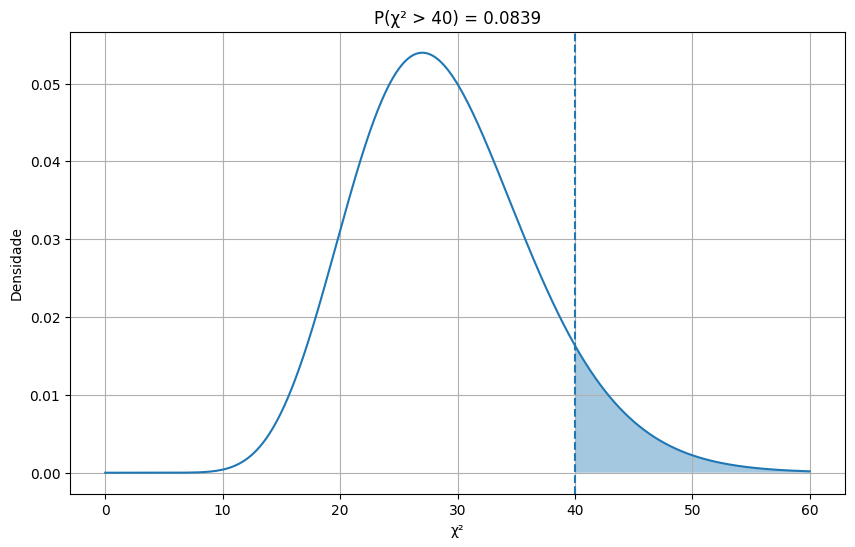

In [81]:
x = np.linspace(0, 60, 1000)
y = chi2.pdf(x, df_chi)

plt.figure(figsize=(10, 6))
plt.plot(x, y)

x_fill = x[x >= limite_chi]
y_fill = chi2.pdf(x_fill, df_chi)

plt.fill_between(x_fill, y_fill, alpha=0.4)

plt.axvline(limite_chi, linestyle="--")

plt.title(f"P(χ² > {limite_chi}) = {prob_chi_acima:.4f}")
plt.xlabel("χ²")
plt.ylabel("Densidade")

plt.show()

In [82]:
percentil_95_chi = chi2.ppf(0.95, df_chi)

print(f"Percentil 95% da distribuição qui-quadrado: {percentil_95_chi:.4f}")

Percentil 95% da distribuição qui-quadrado: 42.5570


### Interpretação

O percentil 95% indica o valor da estatística qui-quadrado abaixo do qual se encontra 95% da distribuição para os graus de liberdade considerados.

Na aplicação à variância, valores da estatística podem ser comparados com valores críticos da distribuição para avaliar a compatibilidade de uma variância amostral com uma variância de referência, desde que as condições necessárias para o procedimento sejam atendidas.

# 6. Distribuição F de Fisher

A distribuição F é uma distribuição contínua definida para valores positivos e caracterizada por dois graus de liberdade:

- \(\nu_1\): graus de liberdade do numerador;
- \(\nu_2\): graus de liberdade do denominador.

Sua função densidade é:

$$
f(x)=\frac{\left(\frac{\nu_1}{\nu_2}\right)^{\nu_1/2}x^{\nu_1/2-1}}{B\left(\frac{\nu_1}{2},\frac{\nu_2}{2}\right)\left(1+\frac{\nu_1}{\nu_2}x\right)^{(\nu_1+\nu_2)/2}}
$$

para:

$$
x>0
$$

em que:

- \(x\) é o valor da variável aleatória;
- \(\nu_1\) são os graus de liberdade do numerador;
- \(\nu_2\) são os graus de liberdade do denominador;
- \(B\) representa a função beta.

Uma aplicação importante da distribuição F ocorre na comparação de duas variâncias.

Neste trabalho será utilizada a razão:

$$
F=\frac{S^2_{\text{tinto}}}{S^2_{\text{branco}}}
$$

em que \(S^2_{\text{tinto}}\) e \(S^2_{\text{branco}}\) representam as variâncias amostrais do teor alcoólico dos dois grupos.

Os graus de liberdade são:

$$
\nu_1=n_{\text{tinto}}-1
$$

$$
\nu_2=n_{\text{branco}}-1
$$

A interpretação dessa estatística pressupõe, entre outras condições, independência das observações e normalidade das populações para a aplicação clássica do teste F de variâncias.

### Referência

SciPy Documentation — `scipy.stats.f`

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f.html

A documentação da SciPy apresenta a distribuição F como uma distribuição contínua parametrizada pelos graus de liberdade do numerador e do denominador.

In [83]:
n_red = len(red)
n_white = len(white)

var_red = red["alcohol"].var(ddof=1)
var_white = white["alcohol"].var(ddof=1)

df1 = n_red - 1
df2 = n_white - 1

f_obs = var_red / var_white

print(f"n tinto = {n_red}")
print(f"n branco = {n_white}")
print(f"Variância do teor alcoólico — tinto: {var_red:.4f}")
print(f"Variância do teor alcoólico — branco: {var_white:.4f}")
print(f"df1 = {df1}")
print(f"df2 = {df2}")
print(f"F observado = {f_obs:.4f}")

n tinto = 1599
n branco = 4898
Variância do teor alcoólico — tinto: 1.1356
Variância do teor alcoólico — branco: 1.5144
df1 = 1598
df2 = 4897
F observado = 0.7499


## 6.1 Efeito dos graus de liberdade do numerador

Para investigar o efeito dos graus de liberdade do numerador, o grau de liberdade do denominador será mantido fixo e apenas \(\nu_1\) será alterado.

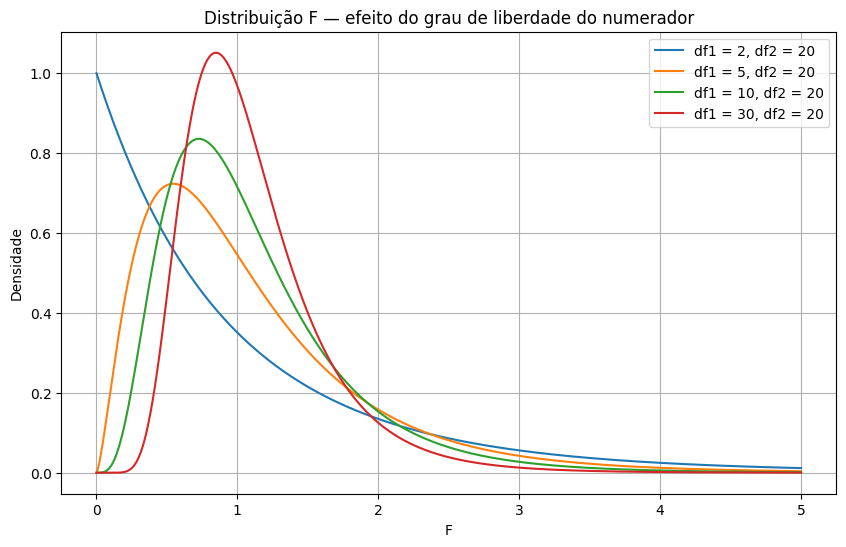

In [84]:
x = np.linspace(0.001, 5, 1000)

df2_fixo = 20
df1_valores = [2, 5, 10, 30]

plt.figure(figsize=(10, 6))

for df1_temp in df1_valores:
    plt.plot(
        x,
        f.pdf(x, df1_temp, df2_fixo),
        label=f"df1 = {df1_temp}, df2 = {df2_fixo}"
    )

plt.xlabel("F")
plt.ylabel("Densidade")
plt.title("Distribuição F — efeito do grau de liberdade do numerador")
plt.legend()

plt.show()

### Interpretação

Mantendo o grau de liberdade do denominador constante, alterações no grau de liberdade do numerador modificam a forma da distribuição F, especialmente sua assimetria e concentração.

A distribuição F é assimétrica à direita e só assume valores positivos.

## 6.2 Efeito dos graus de liberdade do denominador

Agora o grau de liberdade do numerador será mantido constante e apenas \(\nu_2\) será alterado.

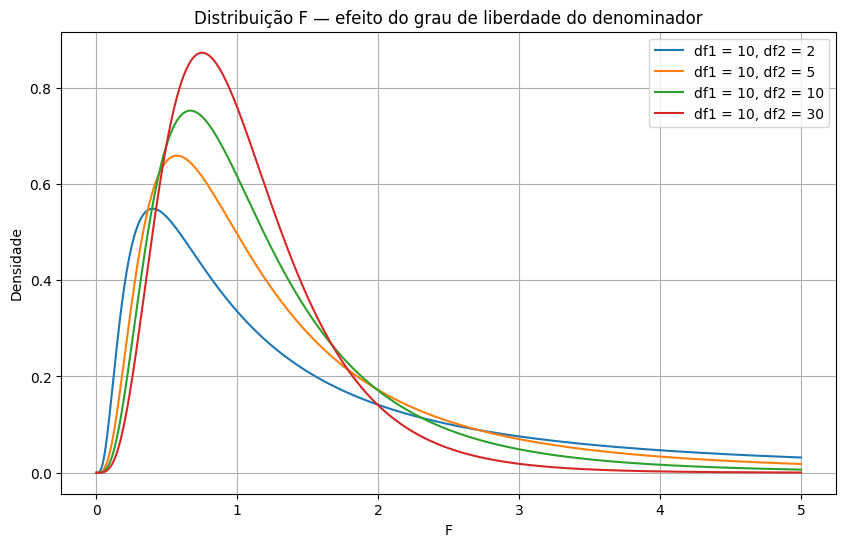

In [85]:
x = np.linspace(0.001, 5, 1000)

df1_fixo = 10
df2_valores = [2, 5, 10, 30]

plt.figure(figsize=(10, 6))

for df2_temp in df2_valores:
    plt.plot(
        x,
        f.pdf(x, df1_fixo, df2_temp),
        label=f"df1 = {df1_fixo}, df2 = {df2_temp}"
    )

plt.xlabel("F")
plt.ylabel("Densidade")
plt.title("Distribuição F — efeito do grau de liberdade do denominador")
plt.legend()

plt.show()

### Interpretação

Alterar o grau de liberdade do denominador também modifica a forma da distribuição F.

Quando os graus de liberdade aumentam, as estimativas de variância envolvidas na razão tendem a apresentar menor variabilidade, modificando a concentração e as caudas da distribuição.

## 6.3 Aplicação da distribuição F

A base apresenta dois grupos independentes de observações:

- vinhos tintos;
- vinhos brancos.

Por isso, é possível calcular a razão entre as variâncias amostrais do teor alcoólico.

Pergunta:

**Qual é a probabilidade, segundo a distribuição F, de uma razão entre variâncias assumir valor menor ou igual à razão observada entre os vinhos tintos e brancos?**

In [86]:
prob_f_acumulada = f.cdf(f_obs, df1, df2)

print(f"P(F ≤ {f_obs:.4f}) = {prob_f_acumulada:.6f}")

P(F ≤ 0.7499) = 0.000000


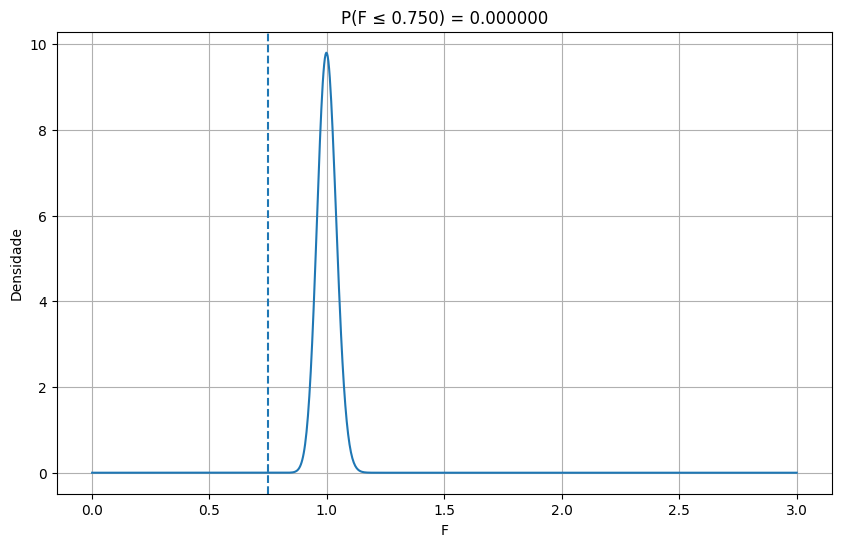

In [87]:
x = np.linspace(0.001, max(3, f_obs * 1.5), 1000)
y = f.pdf(x, df1, df2)

plt.figure(figsize=(10, 6))
plt.plot(x, y)

x_fill = x[x <= f_obs]
y_fill = f.pdf(x_fill, df1, df2)

plt.fill_between(x_fill, y_fill, alpha=0.4)

plt.axvline(f_obs, linestyle="--")

plt.title(f"P(F ≤ {f_obs:.3f}) = {prob_f_acumulada:.6f}")
plt.xlabel("F")
plt.ylabel("Densidade")

plt.show()

## 6.4 Probabilidade entre dois valores

Pergunta:

**Qual é a probabilidade de uma variável F com os graus de liberdade observados assumir valor entre 0,5 e 1,5?**

In [88]:
a_f = 0.5
b_f = 1.5

prob_f_intervalo = f.cdf(b_f, df1, df2) - f.cdf(a_f, df1, df2)

print(f"P({a_f} < F < {b_f}) = {prob_f_intervalo:.6f}")

P(0.5 < F < 1.5) = 1.000000


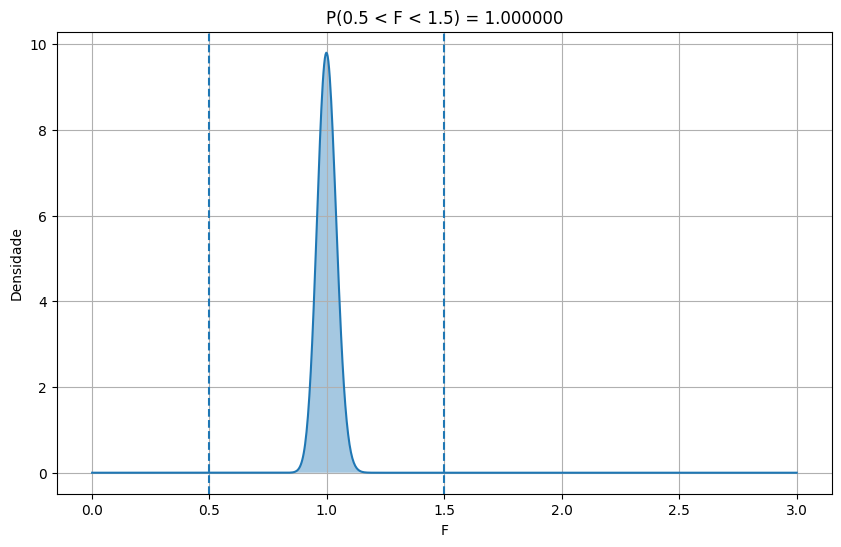

In [89]:
x = np.linspace(0.001, 3, 1000)
y = f.pdf(x, df1, df2)

plt.figure(figsize=(10, 6))
plt.plot(x, y)

x_fill = x[(x >= a_f) & (x <= b_f)]
y_fill = f.pdf(x_fill, df1, df2)

plt.fill_between(x_fill, y_fill, alpha=0.4)

plt.axvline(a_f, linestyle="--")
plt.axvline(b_f, linestyle="--")

plt.title(f"P({a_f} < F < {b_f}) = {prob_f_intervalo:.6f}")
plt.xlabel("F")
plt.ylabel("Densidade")

plt.show()

## 6.5 Probabilidade acima de um valor

Pergunta:

**Qual é a probabilidade de a razão entre as variâncias ser superior a 2?**

In [90]:
limite_f = 2

prob_f_acima = f.sf(limite_f, df1, df2)

print(f"P(F > {limite_f}) = {prob_f_acima:.6f}")

P(F > 2) = 0.000000


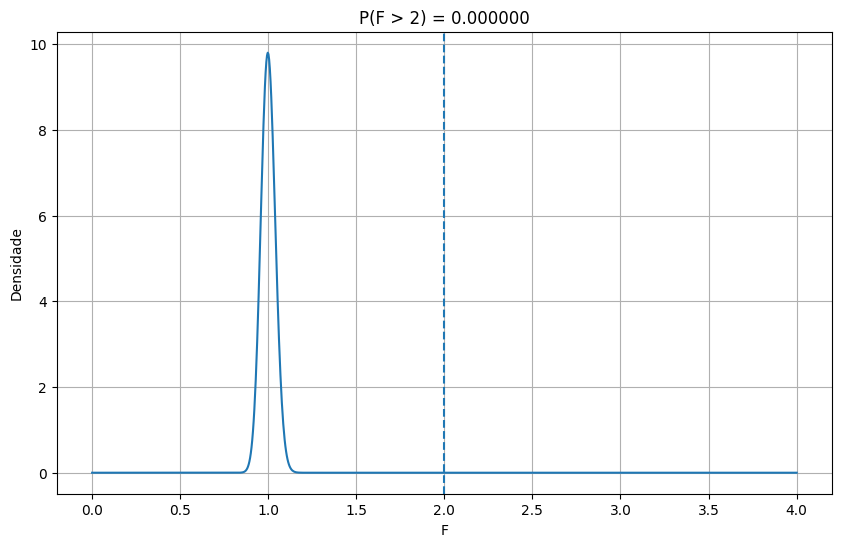

In [91]:
x = np.linspace(0.001, 4, 1000)
y = f.pdf(x, df1, df2)

plt.figure(figsize=(10, 6))
plt.plot(x, y)

x_fill = x[x >= limite_f]
y_fill = f.pdf(x_fill, df1, df2)

plt.fill_between(x_fill, y_fill, alpha=0.4)

plt.axvline(limite_f, linestyle="--")

plt.title(f"P(F > {limite_f}) = {prob_f_acima:.6f}")
plt.xlabel("F")
plt.ylabel("Densidade")

plt.show()

In [92]:
percentil_95_f = f.ppf(0.95, df1, df2)

print(f"Percentil 95% da distribuição F: {percentil_95_f:.4f}")

Percentil 95% da distribuição F: 1.0686


### Interpretação

O percentil 95% da distribuição F representa o valor abaixo do qual se encontra 95% da distribuição F para os graus de liberdade utilizados.

Na comparação de variâncias, valores críticos da distribuição F podem ser utilizados em procedimentos inferenciais para avaliar razões entre variâncias, desde que sejam atendidas as condições estatísticas necessárias.

# 7. Comparação das quatro distribuições

As quatro distribuições estudadas possuem aplicações diferentes.

| Distribuição | Quantidade principal analisada | Característica |
|---|---|---|
| Normal | Valor de uma variável contínua | Simétrica; definida por μ e σ |
| t de Student | Estatística relacionada à média | Possui graus de liberdade e caudas mais pesadas que a Normal para amostras pequenas |
| Qui-quadrado | Estatística relacionada à variância | Assume apenas valores positivos |
| F de Fisher | Razão entre duas variâncias | Assume valores positivos e possui dois graus de liberdade |

A escolha da distribuição depende da quantidade estatística que está sendo modelada.

Uma observação individual de teor alcoólico não deve ser confundida com uma estatística calculada a partir de uma amostra, como uma média, uma variância ou uma razão entre variâncias.

# 8. Comparação visual das distribuições

As distribuições apresentam comportamentos distintos.

A Normal é simétrica em torno da média.

A t de Student também é simétrica, mas apresenta caudas mais pesadas quando possui poucos graus de liberdade.

A qui-quadrado é assimétrica e assume apenas valores positivos.

A F também é assimétrica, assume valores positivos e depende de dois graus de liberdade.

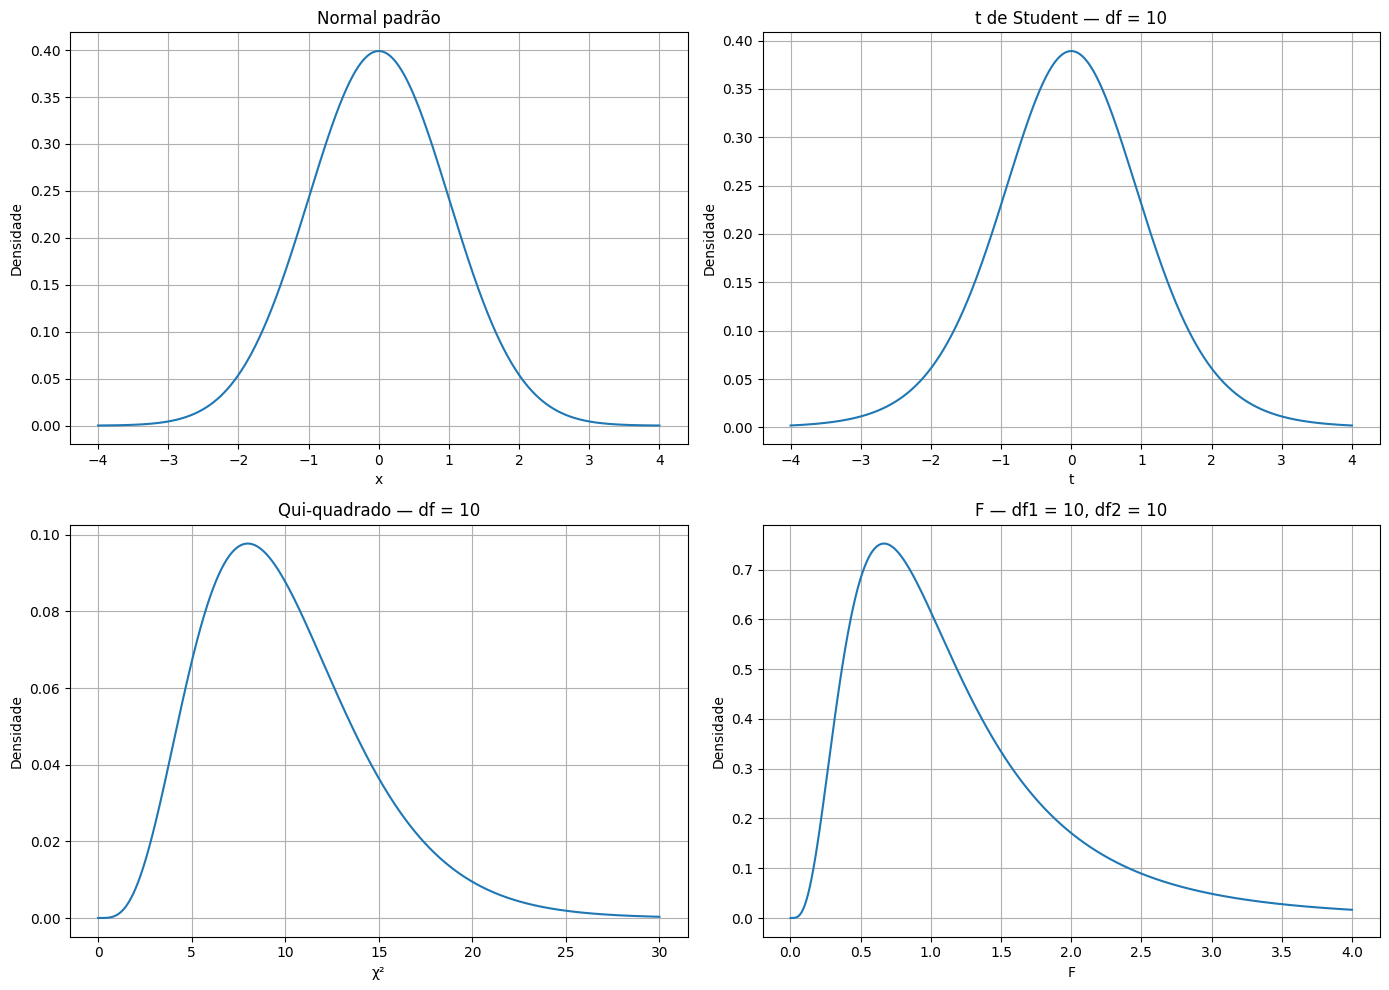

In [93]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Normal
x_normal = np.linspace(-4, 4, 1000)
axes[0, 0].plot(x_normal, norm.pdf(x_normal))
axes[0, 0].set_title("Normal padrão")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("Densidade")

# t
x_t = np.linspace(-4, 4, 1000)
axes[0, 1].plot(x_t, t.pdf(x_t, 10))
axes[0, 1].set_title("t de Student — df = 10")
axes[0, 1].set_xlabel("t")
axes[0, 1].set_ylabel("Densidade")

# Qui-quadrado
x_chi = np.linspace(0, 30, 1000)
axes[1, 0].plot(x_chi, chi2.pdf(x_chi, 10))
axes[1, 0].set_title("Qui-quadrado — df = 10")
axes[1, 0].set_xlabel("χ²")
axes[1, 0].set_ylabel("Densidade")

# F
x_f = np.linspace(0.001, 4, 1000)
axes[1, 1].plot(x_f, f.pdf(x_f, 10, 10))
axes[1, 1].set_title("F — df1 = 10, df2 = 10")
axes[1, 1].set_xlabel("F")
axes[1, 1].set_ylabel("Densidade")

plt.tight_layout()
plt.show()

# 9. Condições e limitações

## Distribuição Normal

A utilização de um modelo Normal pressupõe que a variável analisada possa ser adequadamente representada por uma distribuição contínua aproximadamente simétrica. A distribuição dos dados deve ser avaliada antes da utilização do modelo.

No caso do teor alcoólico dos vinhos, a curva Normal foi utilizada como modelo teórico baseado na média e no desvio-padrão observados. Isso não significa que todas as observações sigam exatamente uma distribuição Normal.

## Distribuição t de Student

A aplicação clássica da distribuição t para inferência sobre uma média pressupõe observações independentes e uma população Normal quando o tamanho da amostra é pequeno. A distribuição também é utilizada em diversos procedimentos assintóticos quando o tamanho amostral é suficientemente grande.

Nesta atividade foi utilizada uma amostra de 25 observações.

## Distribuição qui-quadrado

Para utilizar a distribuição qui-quadrado na inferência clássica sobre uma variância, pressupõe-se que as observações sejam independentes e provenientes de uma população Normal.

Essa condição é especialmente importante porque a distribuição exata da estatística baseada na variância depende da normalidade da população.

## Distribuição F

A comparação clássica de duas variâncias utilizando a distribuição F pressupõe que as duas amostras sejam independentes e que as populações sejam aproximadamente Normais.

Embora a base possua dois grupos reais, vinho tinto e vinho branco, a existência dos grupos não garante automaticamente que todas as condições do procedimento estatístico sejam atendidas.

## Limitações da base

A base possui grande número de observações, mas representa especificamente amostras de vinhos Vinho Verde portugueses. Portanto, os resultados não devem ser generalizados automaticamente para todos os vinhos produzidos no mundo.

Além disso, os dados disponíveis são principalmente físico-químicos e uma avaliação de qualidade, não contendo informações como marca, variedade de uva, preço ou características completas do processo produtivo.

Outra limitação é que a base possui números diferentes de observações para vinhos tintos e brancos, o que deve ser considerado na comparação entre os grupos.

# 10. Conclusão

A análise mostrou que as distribuições de probabilidade possuem aplicações diferentes no estudo de dados da área de alimentos.

A distribuição Normal foi utilizada para modelar teor alcoólico, permitindo calcular probabilidades associadas a valores individuais da variável.

A distribuição t de Student foi utilizada para representar uma estatística relacionada à média amostral do teor alcoólico, considerando a variabilidade estimada a partir da própria amostra.

A distribuição qui-quadrado foi aplicada a uma estatística relacionada à variância amostral, mostrando como essa distribuição pode ser utilizada em problemas envolvendo a variabilidade de uma característica físico-química.

A distribuição F foi utilizada na comparação das variâncias dos teores alcoólicos de vinhos tintos e brancos, aproveitando a existência de dois grupos de observações individuais na base.

Também foi possível observar que os parâmetros das distribuições modificam suas características de maneiras diferentes. Na Normal, a média altera a posição da curva e o desvio-padrão altera sua dispersão. Na t, os graus de liberdade controlam principalmente o comportamento das caudas. Na qui-quadrado, os graus de liberdade influenciam sua posição e assimetria. Na F, os graus de liberdade do numerador e do denominador influenciam separadamente a forma da distribuição.

Por fim, as curvas e probabilidades calculadas não são suficientes para afirmar que os dados reais seguem exatamente uma determinada distribuição. A aplicação de cada modelo depende das características dos dados, da quantidade estatística analisada e das condições necessárias para o procedimento estatístico.

# 11. Referências

## Base de dados

CORTEZ, P.; CERDEIRA, A.; ALMEIDA, F.; MATOS, T.; REIS, J. Wine Quality. UCI Machine Learning Repository, 2009. DOI: 10.24432/C56S3T. Disponível em:

https://archive.ics.uci.edu/dataset/186/wine+quality

Acesso em: 30 set. 2026.

## Distribuição Normal

SCIPY. SciPy Documentation — `scipy.stats.norm`. Disponível em:

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html

Acesso em: 30 set. 2026.

## Distribuição t de Student

SCIPY. SciPy Documentation — `scipy.stats.t`. Disponível em:

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html

Acesso em: 30 set. 2026.

## Distribuição qui-quadrado

SCIPY. SciPy Documentation — `scipy.stats.chi2`. Disponível em:

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2.html

Acesso em: 30 set. 2026.

## Distribuição F

SCIPY. SciPy Documentation — `scipy.stats.f`. Disponível em:

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f.html

Acesso em: 30 set. 2026.